In [11]:
import numpy as np

class ProbabilityNode:
    def __init__(self, data: float):
        self.data = data
        self.left = None
        self.right = None
        self.parent = None

In [12]:
# Construction de l'arbre
coeffs = [1,2,3,4,5]

depth = np.ceil(np.log2(len(coeffs)))

# Step 1: Normalise
s = sum(coeffs)
for i in range(len(coeffs)):
    coeffs[i] = coeffs[i] / s

# Step 2: Prepare the leaves
leaves = []

for i in range(int(2**depth)):
    if i < len(coeffs):
        leaves.append(ProbabilityNode(coeffs[i]))
    else:
        leaves.append(ProbabilityNode(0))

# Step 3: Construct the tree
previous_layer = leaves
for i in range(int(depth)):
    new_layer = []
    for j in range(0, len(previous_layer), 2):
        parent = ProbabilityNode(
            previous_layer[j].data + previous_layer[j + 1].data
        )
        previous_layer[j].parent = parent
        previous_layer[j + 1].parent = parent
        parent.left = previous_layer[j]
        parent.right = previous_layer[j + 1]
        new_layer.append(parent)

    previous_layer = new_layer

root = new_layer[0]

print(root.data)
print(root.right.data)

1.0
0.3333333333333333


In [13]:
from qiskit.quantum_info import SparsePauliOp
print(list(SparsePauliOp(["XX","YY"], [1,2]).coeffs))

[np.complex128(1+0j), np.complex128(2+0j)]


In [14]:
j =2
ctrl_state = np.array(list(f"{j:b}")[::-1], dtype=int)

print(ctrl_state)
print(np.nonzero(ctrl_state)[0])

[0 1]
[1]


In [15]:
from block_encoding.oracles.prepare import build_prepare_oracle

matr = SparsePauliOp(["XXX", "XYX", "XZZ", "IZZ", "ZYZ", "XII", "XXI", "IIY", "IXI","IIZ"], [1,2,3,4,5,6,7,8,9,10])
circuit = build_prepare_oracle(matr)
circuit.draw('mpl')

AttributeError: 'tuple' object has no attribute 'draw'

In [ ]:
j=7
ctrl_state = np.array(list(f"{j:0{6}b}")[::-1], dtype=int)
print(np.nonzero(ctrl_state)[0])

[0 1 2]


In [ ]:
matrix = SparsePauliOp(["XX","YY","ZZ","ZI","IZ"],[1,2,3,4,5])
num_qubit_index = len(f"{len(matrix.coeffs):b}")
print(num_qubit_index)

3


In [ ]:
print(list(range(5)))

[0, 1, 2, 3, 4]


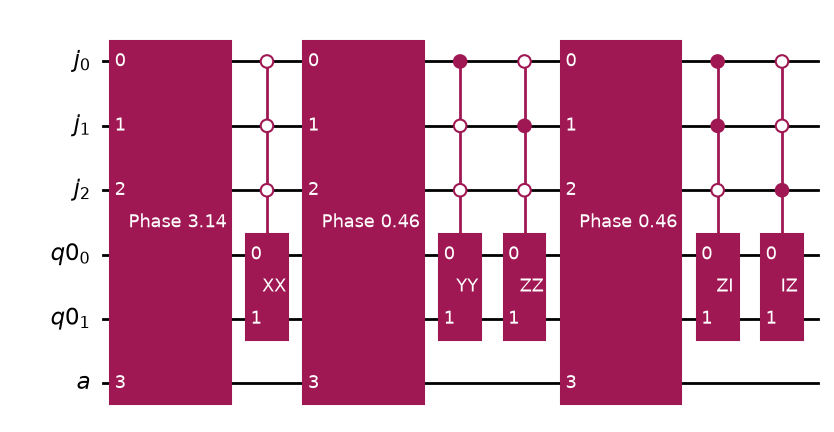

In [18]:
from block_encoding.oracles.select import build_select_oracle

matrix = SparsePauliOp(["XX","YY","ZZ","ZI","IZ"],[-1,2+1j,3,4+2j,5])
circuit = build_select_oracle(matrix)
circuit.draw('mpl')


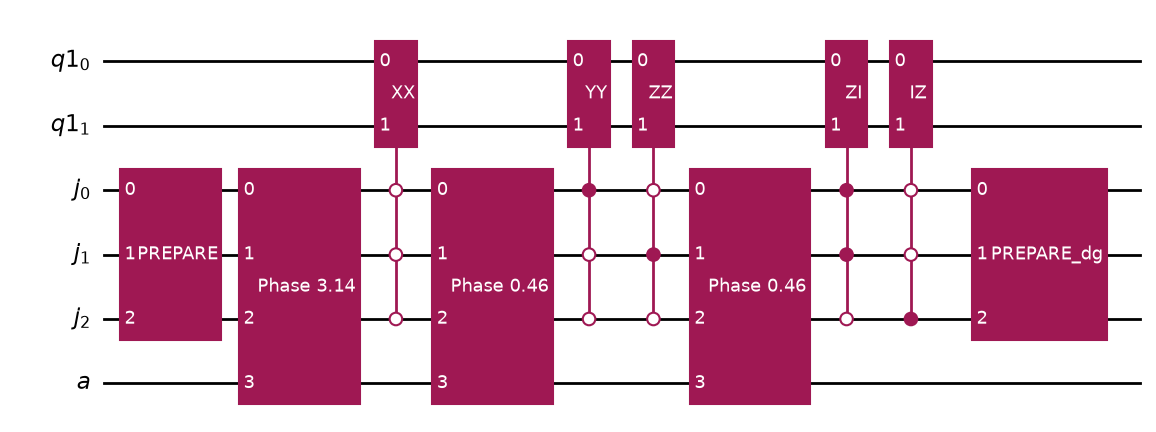

In [19]:
from block_encoding.encode_lcu import encode_LCU

circuit, s = encode_LCU(matrix)

circuit.draw('mpl')

In [ ]:
from qiskit.quantum_info import Operator
matr = Operator(circuit).data
print(matr)

[[ 7.63932023e-01+1.27322004e-01j -2.46174845e-02+1.04281338e-01j
   2.93263453e-01+8.37895581e-02j ... -5.23599808e-18+1.31225679e-17j
  -1.75401875e-17-1.05045689e-17j  2.80121836e-17-4.38504686e-18j]
 [-2.46174845e-02+1.04281338e-01j  7.73826058e-01+8.54101966e-02j
  -1.62005630e-02+6.86266862e-02j ... -3.50152295e-18-1.39572328e-17j
   4.88910305e-17+1.57079942e-17j -4.18879846e-17+1.22227576e-17j]
 [ 2.93263453e-01+8.37895581e-02j -1.62005630e-02+6.86266862e-02j
   5.11299264e-01+5.51412155e-02j ...  7.95633468e-18-1.99403324e-17j
   2.66531041e-17+1.59621650e-17j -4.25657734e-17+6.66327602e-18j]
 ...
 [-2.37041702e-18-1.26497275e-17j  1.19633736e-17-1.47087891e-18j
   7.24479731e-18+8.04682446e-17j ... -4.09016994e-01-6.11823875e-01j
   1.07079458e-01+8.93659832e-02j -1.67843013e-16-4.37419639e-02j]
 [-1.81450630e-17-1.28544125e-17j -2.71837729e-17-1.32968969e-17j
  -8.70557164e-17-9.13288930e-17j ...  1.07079458e-01+8.93659832e-02j
  -3.80695094e-01-5.50505429e-01j  7.04681058e-